In [ ]:
# -------------------------
# 1. Imports & Device Setup
# -------------------------
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from pytorch_msssim import ssim
from torch.utils.tensorboard import SummaryWriter
import torch.nn.functional as F
from torchvision.models import VGG19_Weights
import math

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
# -------------------------
# 2. Dataset and Augmentation (Robust Matching)
# -------------------------
class ColorizationDataset(Dataset):
    def __init__(self, gray_folder, color_folder, image_size=128):
        self.gray_folder = gray_folder
        self.color_folder = color_folder
        self.image_size = image_size

        # Match only common filenames in both folders
        gray_files = sorted(os.listdir(gray_folder))
        color_files = sorted(os.listdir(color_folder))
        self.filenames = sorted(list(set(gray_files) & set(color_files)))

        assert len(self.filenames) > 0, "No matching grayscale and color image pairs found!"

                # For grayscale
        self.gray_transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5])
        ])

        # For color
        self.color_transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5] * 3, [0.5] * 3)
        ])


    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        filename = self.filenames[idx]
        gray_path = os.path.join(self.gray_folder, filename)
        color_path = os.path.join(self.color_folder, filename)

        gray = Image.open(gray_path).convert('L')
        color = Image.open(color_path).convert('RGB')

        gray_tensor = self.gray_transform(gray).repeat(3, 1, 1)  # Convert to 3-channel
        color_tensor = self.color_transform(color)

        return gray_tensor, color_tensor


In [ ]:
def visualize_sample(dataset, n=4):
    fig, ax = plt.subplots(2, n, figsize=(15, 5))
    for i in range(n):
        g, c = dataset[i]
        ax[0][i].imshow(g.permute(1,2,0).numpy() * 0.5 + 0.5)
        ax[0][i].set_title("Grayscale")
        ax[1][i].imshow(c.permute(1,2,0).numpy() * 0.5 + 0.5)
        ax[1][i].set_title("Color")
        ax[0][i].axis('off')
        ax[1][i].axis('off')
    plt.tight_layout()
    plt.show()


In [ ]:
# -------------------------
# 3. Model Architecture: CNN Encoder + Transformer + CNN Decoder
# -------------------------
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1)
        )
    def forward(self, x):
        return x + self.block(x)

class CNNEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.ReLU(),
            ResidualBlock(128),
            ResidualBlock(128)
        )
    def forward(self, x):
        return self.encoder(x)

class TransformerBlock(nn.Module):
    def __init__(self, channels, heads=4, layers=2):
        super().__init__()
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=channels, nhead=heads, dim_feedforward=channels*4, batch_first=True),
            num_layers=layers
        )
    def forward(self, x):
        b, c, h, w = x.shape
        x = x.view(b, c, -1).permute(0, 2, 1)
        x = self.transformer(x)
        x = x.permute(0, 2, 1).view(b, c, h, w)
        return x

class CNNDecoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 3, 3, padding=1),
            nn.Tanh()
        )
    def forward(self, x):
        return self.decoder(x)

class ColorizationModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = CNNEncoder()
        self.downsample = nn.Sequential(
            nn.Conv2d(128, 128, 3, stride=2, padding=1),
            nn.ReLU()
        )
        self.transformer = TransformerBlock(128, heads=4, layers=2)
        self.upsample = nn.Sequential(
            nn.ConvTranspose2d(128, 128, 4, stride=2, padding=1),
            nn.ReLU()
        )
        self.decoder = CNNDecoder()
    def forward(self, x):
        x = self.encoder(x)
        x = self.downsample(x)
        x = self.transformer(x)
        x = self.upsample(x)
        return self.decoder(x)


In [ ]:
# -------------------------
# 4. Loss Functions and Metrics
# -------------------------
def hybrid_loss(output, target):
    l1 = nn.L1Loss()(output, target)
    ssim_val = 1 - ssim(output, target, data_range=2.0, size_average=True)
    return 0.7 * l1 + 0.3 * ssim_val

# Optional: Perceptual Loss (VGG-based). Enable by setting use_perceptual=True in training.
class PerceptualLoss(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = models.vgg19(weights=VGG19_Weights.DEFAULT).features[:9].eval()
        for param in vgg.parameters():
            param.requires_grad = False
        self.vgg = vgg.to(device)

    def forward(self, output, target):
        return F.l1_loss(self.vgg(output), self.vgg(target))


def calculate_psnr(output, target):
    mse = torch.mean((output - target) ** 2)
    if mse == 0:
        return 100
    return 20 * torch.log10(2.0 / torch.sqrt(mse))  # data_range=2.0 since images normalized to [-1,1]


In [ ]:
def train_model(model, dataloader, optimizer, scaler, epochs=80, writer=None, use_perceptual=False):
    model.train()
    best_loss = float("inf")
    sample_batch = next(iter(dataloader))[0][:1].to(device)
    perceptual_loss_fn = PerceptualLoss() if use_perceptual else None

    for epoch in range(epochs):
        running_loss, total_ssim, total_psnr = 0.0, 0.0, 0.0
        progress = tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}")

        for gray, color in progress:
            gray, color = gray.to(device), color.to(device)
            optimizer.zero_grad()

            with torch.cuda.amp.autocast():
                output = model(gray)
                loss = hybrid_loss(output, color)  # Hybrid = L1 + SSIM (inside, we fix types)

                if perceptual_loss_fn is not None:
                    # Cast to float32 to avoid half precision issues with perceptual loss
                    output_vgg = (output + 1).float() / 2
                    color_vgg = (color + 1).float() / 2
                    loss += 0.01 * perceptual_loss_fn(output_vgg, color_vgg)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item()

            # Cast to float32 for SSIM/PSNR computation
            batch_ssim = ssim(output.float(), color.float(), data_range=2.0, size_average=True).item()
            batch_psnr = calculate_psnr(output.float(), color.float()).item()

            total_ssim += batch_ssim
            total_psnr += batch_psnr

            progress.set_postfix({
                "Loss": running_loss / len(dataloader),
                "SSIM": total_ssim / len(dataloader),
                "PSNR": total_psnr / len(dataloader)
            })

        avg_loss = running_loss / len(dataloader)

        if avg_loss < best_loss:
            best_loss = avg_loss
            torch.save(model.state_dict(), "best_colorization_model.pth")

    if writer:
        writer.close()


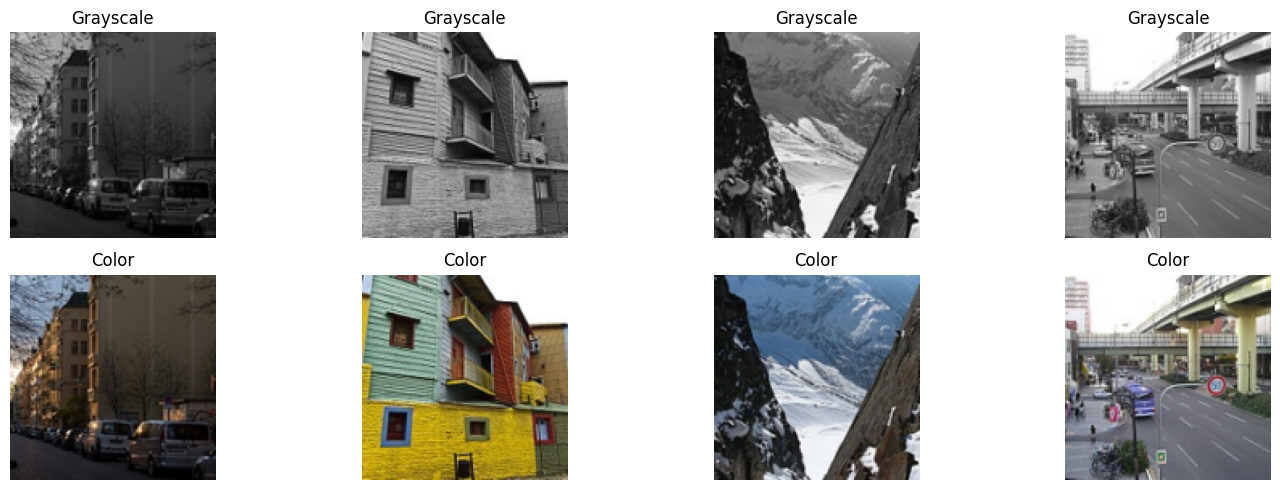

<ipython-input-7-faeb1e86c5fb>:21: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [ ]:
# -------------------------
# 6. Hyperparameters and Training
# -------------------------
# Update these paths to your dataset locations (e.g., on Google Drive)
gray_folder = "/content/drive/MyDrive/LandScape_Images/Gray/Gray_img"    # Contains 7100 grayscale images
color_folder = "/content/drive/MyDrive/LandScape_Images/Color/Color_img"   # Contains corresponding color images

IMAGE_SIZE = 128
BATCH_SIZE = 16   # Adjust to 8 if memory issues occur
EPOCHS = 50

# Create Dataset and DataLoader
dataset = ColorizationDataset(gray_folder, color_folder, image_size=IMAGE_SIZE)
visualize_sample(dataset, n=4)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)

# Initialize model, optimizer, scheduler, and scaler
model = ColorizationModel().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.6)
scaler = torch.cuda.amp.GradScaler()


In [ ]:
# Train the model. Set use_perceptual=True if you want to add perceptual loss.
train_model(model, loader, optimizer, scaler, epochs=EPOCHS, use_perceptual=True)

Epoch 1/50:   0%|          | 0/446 [00:00<?, ?it/s]<ipython-input-54-35b065f25ad3>:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
Epoch 50/50: 100%|██████████| 446/446 [00:56<00:00,  7.88it/s, Loss=0.0875, SSIM=0.869, PSNR=25.7]


<ipython-input-8-ab0559d0437e>:35: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('/content/drive/MyDrive/Colab Notebooks/best_colorization_m

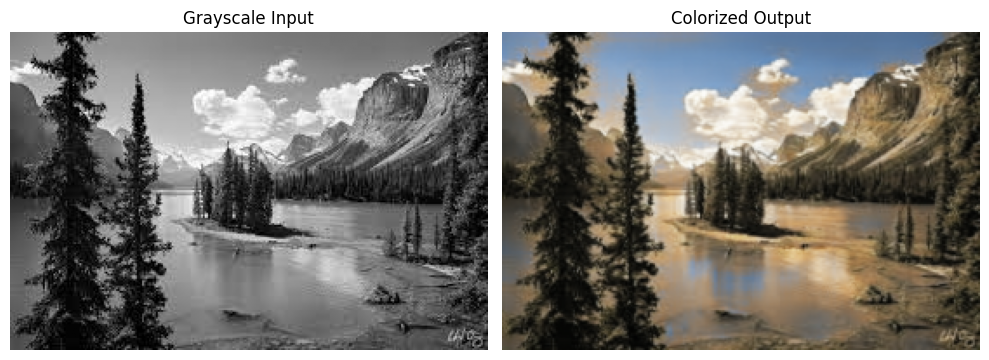

In [ ]:
# -------------------------
# 7. Validation: Test on an External Grayscale Image
# -------------------------
def validate_model(model, image_path):
    model.eval()
    img = Image.open(image_path).convert("L")
    orig_size = img.size
    transform = transforms.Compose([
        transforms.Resize((256,256)),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])
    ])
    input_tensor = transform(img).repeat(3,1,1).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(input_tensor)
    output_img = output.squeeze().permute(1,2,0).cpu().numpy()
    output_img = ((output_img + 1) * 127.5).astype(np.uint8)
    output_img = Image.fromarray(output_img).resize(orig_size)

    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.imshow(img, cmap="gray")
    plt.title("Grayscale Input")
    plt.axis("off")
    plt.subplot(1,2,2)
    plt.imshow(output_img)
    plt.title("Colorized Output")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

# Provide the path to an external grayscale image (outside of your dataset)
external_image_path = "/content/drive/MyDrive/LandScape_Images/testing.jpeg"
# Load the best model weights
model.load_state_dict(torch.load('/content/drive/MyDrive/Colab Notebooks/best_colorization_model.pth'))
# Validate the model
validate_model(model, external_image_path)


In [ ]:
model.load_state_dict(torch.load('/content/drive/MyDrive/Colab Notebooks/best_colorization_model.pth'))
model.to(device)

<ipython-input-9-7c5b8d1ff61b>:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('/content/drive/MyDrive/Colab Notebooks/best_colorization_mo

ColorizationModel(
  (encoder): CNNEncoder(
    (encoder): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
      (4): ResidualBlock(
        (block): Sequential(
          (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): ReLU(inplace=True)
          (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        )
      )
      (5): ResidualBlock(
        (block): Sequential(
          (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): ReLU(inplace=True)
          (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        )
      )
    )
  )
  (downsample): Sequential(
    (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
  )
  (transformer): TransformerBlock(
    (transformer): Tran

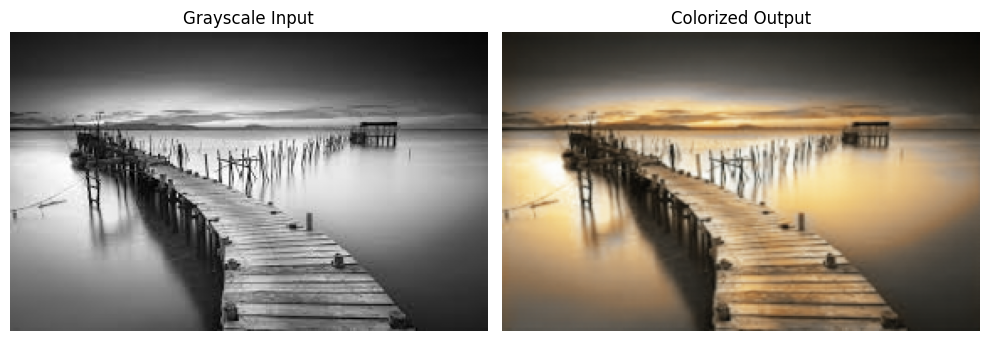

In [ ]:
# -------------------------
# 7. Validation: Test on an External Grayscale Image
# -------------------------
def validate_model(model, image_path):
    model.eval()
    img = Image.open(image_path).convert("L")
    orig_size = img.size
    transform = transforms.Compose([
        transforms.Resize((256,256)),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])
    ])
    input_tensor = transform(img).repeat(3,1,1).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(input_tensor)
    output_img = output.squeeze().permute(1,2,0).cpu().numpy()
    output_img = ((output_img + 1) * 127.5).astype(np.uint8)
    output_img = Image.fromarray(output_img).resize(orig_size)

    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.imshow(img, cmap="gray")
    plt.title("Grayscale Input")
    plt.axis("off")
    plt.subplot(1,2,2)
    plt.imshow(output_img)
    plt.title("Colorized Output")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

# Provide the path to an external grayscale image (outside of your dataset)
external_image_path = "/content/drive/MyDrive/LandScape_Images/testing3.jpeg"
# Validate the model
validate_model(model, external_image_path)


<ipython-input-11-e15f0102e6b2>:35: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('/content/drive/MyDrive/Colab Notebooks/best_colorization_

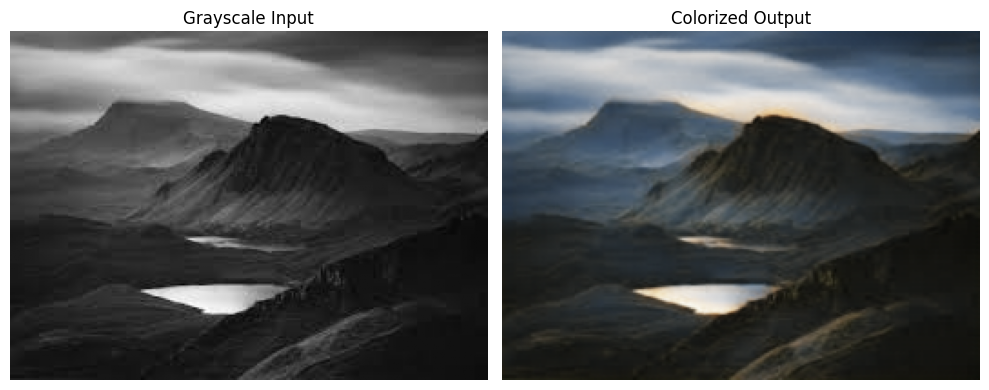

In [ ]:
# -------------------------
# 7. Validation: Test on an External Grayscale Image
# -------------------------
def validate_model(model, image_path):
    model.eval()
    img = Image.open(image_path).convert("L")
    orig_size = img.size
    transform = transforms.Compose([
        transforms.Resize((256,256)),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])
    ])
    input_tensor = transform(img).repeat(3,1,1).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(input_tensor)
    output_img = output.squeeze().permute(1,2,0).cpu().numpy()
    output_img = ((output_img + 1) * 127.5).astype(np.uint8)
    output_img = Image.fromarray(output_img).resize(orig_size)

    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.imshow(img, cmap="gray")
    plt.title("Grayscale Input")
    plt.axis("off")
    plt.subplot(1,2,2)
    plt.imshow(output_img)
    plt.title("Colorized Output")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

# Provide the path to an external grayscale image (outside of your dataset)
external_image_path = "/content/drive/MyDrive/LandScape_Images/testing4.jpeg"
# Load the best model weights
model.load_state_dict(torch.load('/content/drive/MyDrive/Colab Notebooks/best_colorization_model.pth'))
# Validate the model
validate_model(model, external_image_path)
